In [4]:
import os
import time
import numpy as np
import pandas as pd

# --- GBM imports ---
from gbm.data import TTE, Cspec, RSP, GbmDetectorCollection
from gbm.binning.unbinned import bin_by_time
from gbm.background import BackgroundFitter
from gbm.background.binned import Polynomial
from gbm.spectra.fitting import SpectralFitterCstat
from gbm.spectra.functions import Band

# ============================================================
# === CONFIGURACIÓN DE ARCHIVOS ===
# ============================================================

fitn9 = os.path.join('..', 'data', 'glg_tte_n9_bn201216963_v00.fit')
tte9 = TTE.open(fitn9)

test_pha_n9 = os.path.join('..', 'data', 'glg_cspec_n9_bn201216963_v00.pha')
test_pha_na = os.path.join('..', 'data', 'glg_cspec_na_bn201216963_v00.pha')
test_pha_b1 = os.path.join('..', 'data', 'glg_cspec_b1_bn201216963_v00.pha')
n9 = Cspec.open(test_pha_n9)
na = Cspec.open(test_pha_na)
b1 = Cspec.open(test_pha_b1)

cspecs = GbmDetectorCollection.from_list([n9, na, b1])
phaii9 = tte9.to_phaii(bin_by_time, 1.024, time_ref=0.0)

erange_nai = (8.0, 900.0)
erange_bgo = (325., 25000.)

# ============================================================
# === FUNCIÓN AUXILIAR: CÁLCULO DE T90 ===
# ============================================================

def get_T90(phaii):
    """
    Compute T5, T95, and T90 for a GBM light curve
    """
    times = phaii.data.time_centroids
    counts = phaii.data.counts.sum(axis=1)

    cumulative = np.cumsum(counts)
    cumulative = (cumulative - cumulative.min()) / (cumulative.max() - cumulative.min())

    T5  = np.interp(0.05, cumulative, times)
    T95 = np.interp(0.95, cumulative, times)
    T90 = T95 - T5
    return float(T5), float(T95), float(T90)

# ============================================================
# === PASO 1. AJUSTE DE BACKGROUND ===
# ============================================================

T5, T95, T90 = get_T90(phaii9)
bkgd_range = [(T5 - 50, T5 - 10), (T95 + 10, T95 + 50)]

backfitters = [BackgroundFitter.from_phaii(cspec, Polynomial, time_ranges=bkgd_range) for cspec in cspecs]
backfitters = GbmDetectorCollection.from_list(backfitters, dets=cspecs.detector())
backfitters.fit(order=1)

bkgds = backfitters.interpolate_bins(cspecs.data()[0].tstart, cspecs.data()[0].tstop)
bkgds = GbmDetectorCollection.from_list(bkgds, dets=cspecs.detector())

# ============================================================
# === PASO 2. DETECCIÓN AUTOMÁTICA DEL BURST ===
# ============================================================

counts = phaii9.data.counts.sum(axis=1)
times = phaii9.time_range[0] + np.arange(len(counts)) * 1.0

bkg_level = np.percentile(counts, 10)
threshold = bkg_level + 3 * np.std(counts[counts < np.percentile(counts, 50)])

mask = counts > threshold
if not np.any(mask):
    raise RuntimeError("No se detectó ningún destello")

#burst_start = times[np.argmax(mask)]
#burst_end = times[len(mask) - np.argmax(mask[::-1]) - 1] + 1.0
burst_start = -10.0
burst_end = 50.0

print(f"💥 Burst detectado entre {burst_start:.2f} s y {burst_end:.2f} s")

# ============================================================
# === PASO 3. DEFINICIÓN DE INTERVALOS ===
# ============================================================

time_edges = np.arange(burst_start, burst_end, 2.0)
time_ranges = [(t, t + 2.0) for t in time_edges if t + 2.0 <= burst_end]

# ============================================================
# === PASO 4. CONFIGURACIÓN DE RESPUESTAS Y MODELO ===
# ============================================================

rsp_dir_n9 = os.path.join('..', 'data', 'glg_cspec_n9_bn201216963_v02.rsp2')
rsp_dir_na = os.path.join('..', 'data', 'glg_cspec_na_bn201216963_v02.rsp2')
rsp_dir_b1 = os.path.join('..', 'data', 'glg_cspec_b1_bn201216963_v02.rsp2')

rsp1 = RSP.open(rsp_dir_n9)
rsp2 = RSP.open(rsp_dir_na)
rsp3 = RSP.open(rsp_dir_b1)
rsps = GbmDetectorCollection.from_list([rsp1, rsp2, rsp3])

model = Band()
model.default_values = [0.01, 500.0, -0.5, -2.0, 100.0]

results = []

# ============================================================
# === OPTIMIZACIÓN 1: Precalcular respuestas interpoladas ===
# ============================================================

rsps_interpoladas = []
for (t0, t1) in time_ranges:
    tcent = (t0 + t1) / 2
    rsps_interpoladas.append([rsp.interpolate(tcent) for rsp in rsps])

# ============================================================
# === PASO 5. LOOP DE AJUSTES ESPECTRALES ===
# ============================================================

for i, (t0, t1) in enumerate(time_ranges):

    phas = cspecs.to_pha(time_ranges=[(t0, t1)], nai_kwargs={'energy_range':erange_nai}, bgo_kwargs={'energy_range':erange_bgo})

    rsps_interp = rsps_interpoladas[i]  # Usar precálculo

    fitter = SpectralFitterCstat(phas, bkgds.to_list(), rsps_interp, method='TNC')

    try:
        start_time = time.time()

        # OPTIMIZACIÓN 2: Reducir número máximo de iteraciones
        try:
            fitter.fit(model, options={'maxiter': 500})
        except Exception as e:
            print(f"⚠️ Error interno en fit: {e}")
            continue

        # Timeout
        if time.time() - start_time > 10:
            print("⏰ Timeout del fit — se detiene este intervalo.")
            continue

        # Validar convergencia
        if not np.isfinite(fitter.statistic):
            print("⚠️ Fit no válido (stat no finita)")
            continue
        if fitter.covariance is None or np.isnan(fitter.covariance).any():
            print("⚠️ Covarianza inválida.")
            continue

        # === Calcular errores relativos (solo alpha, beta y Epeak) ===
        errs = np.array(fitter.asymmetric_errors(cl=0.9), dtype=float)
        params = np.array(fitter.parameters)

        if len(errs) != len(params):
            print(f"⚠️ Inconsistencia: {len(errs)} errores para {len(params)} parámetros.")
            continue

        rel_errs = np.mean(np.abs(errs) / np.abs(params[:, None]), axis=1)

        # Índices del modelo Band → [A, Epeak, alpha, beta, Epiv]
        indices_eval = [1, 2]
        rel_errs_eval = rel_errs[indices_eval]
        max_rel = np.max(rel_errs_eval)

        # === Guardar resultados válidos ===
        if max_rel < 0.2:
            res = {
                "t_start": t0,
                "t_stop": t1,
                "Cstat": fitter.statistic,
                "dof": fitter.dof,
            }

            # Parámetros y errores
            for name, val in zip(model.param_list, fitter.parameters):
                res[name[0]] = float(val)

            for i, (name, val) in enumerate(zip(model.param_list, fitter.parameters)):
                err_low, err_high = errs[i]
                rel_err_mean = rel_errs[i] * 100
                res[f"{name[0]}_err_low"] = float(err_low)
                res[f"{name[0]}_err_high"] = float(err_high)
                res[f"{name[0]}_err_rel(%)"] = float(rel_err_mean)

            results.append(res)
            print(f"{t0:.3f}–{t1:.3f} s: ✅ Fit guardado.")
        else:
            print(f"{t0:.3f}–{t1:.3f} s: ❌ Errores grandes ({max_rel*100:.1f}%)")

    except Exception as e:
        print(f"Error en {t0}-{t1}: {e}")
        continue

# ============================================================
# === PASO 6. GUARDAR RESULTADOS ===
# ============================================================

if results:
    df = pd.DataFrame(results)
    df.to_csv("valid_fits_2012.csv", index=False)
    print(f"✅ {len(df)} valid fits saved to 'valid_fits_2012.csv'")
else:
    print("⚠️ No valid fits found.")


💥 Burst detectado entre -10.00 s y 50.00 s
-10.000–-8.000 s: ❌ Errores grandes (1809.5%)
-8.000–-6.000 s: ❌ Errores grandes (51166.8%)
Error en -6.0--4.0: singular matrix
-4.000–-2.000 s: ❌ Errores grandes (206.2%)
-2.000–0.000 s: ❌ Errores grandes (85.6%)
0.000–2.000 s: ❌ Errores grandes (37.7%)
2.000–4.000 s: ❌ Errores grandes (21.0%)
4.000–6.000 s: ✅ Fit guardado.
6.000–8.000 s: ✅ Fit guardado.
8.000–10.000 s: ✅ Fit guardado.
10.000–12.000 s: ✅ Fit guardado.
12.000–14.000 s: ✅ Fit guardado.
14.000–16.000 s: ✅ Fit guardado.
16.000–18.000 s: ✅ Fit guardado.
18.000–20.000 s: ✅ Fit guardado.
20.000–22.000 s: ✅ Fit guardado.
22.000–24.000 s: ✅ Fit guardado.
24.000–26.000 s: ✅ Fit guardado.
26.000–28.000 s: ✅ Fit guardado.
28.000–30.000 s: ✅ Fit guardado.
30.000–32.000 s: ✅ Fit guardado.
32.000–34.000 s: ✅ Fit guardado.
34.000–36.000 s: ✅ Fit guardado.
36.000–38.000 s: ✅ Fit guardado.
38.000–40.000 s: ❌ Errores grandes (26.0%)
40.000–42.000 s: ❌ Errores grandes (30.0%)
42.000–44.000 s: ❌ 

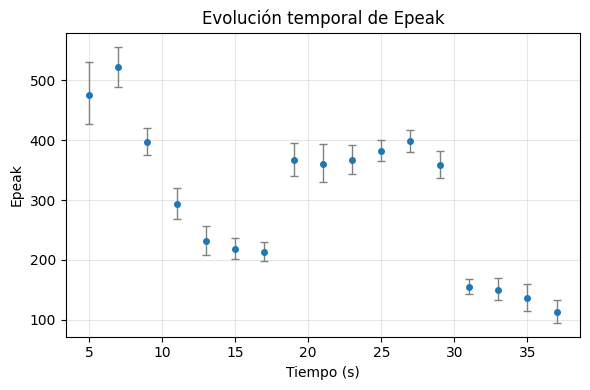

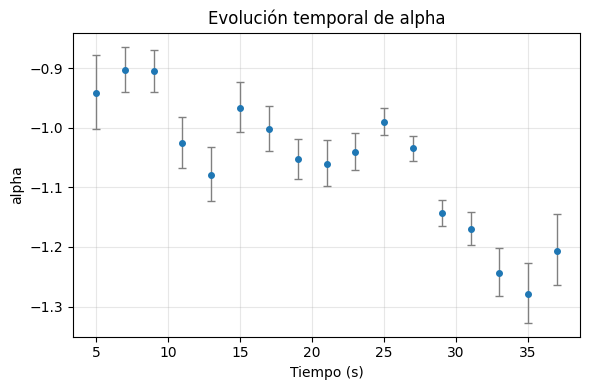

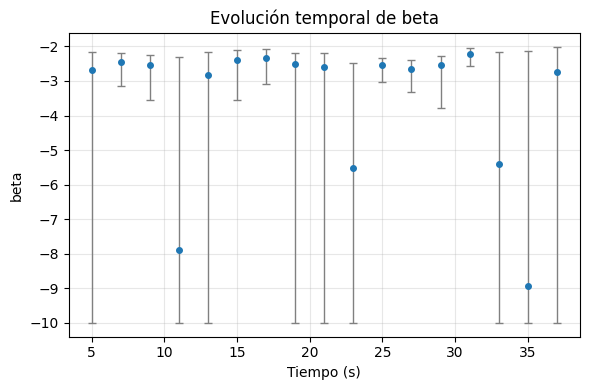

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar resultados
df = pd.read_csv("valid_fits_2012.csv")

# Calcular tiempo central de cada bin
df["t_center"] = 0.5 * (df["t_start"] + df["t_stop"])

# === Graficar cada parámetro ===
params = ["Epeak", "alpha", "beta"]

for p in params:
    if p not in df.columns:
        print(f"⚠️ {p} no está en el CSV, se omite.")
        continue

    err_low = df[f"{p}_err_low"].abs()
    err_high = df[f"{p}_err_high"].abs()

    plt.figure(figsize=(6, 4))
    plt.errorbar(
        df["t_center"],
        df[p],
        yerr=[err_low, err_high],
        fmt="o",
        ecolor="gray",
        elinewidth=1,
        capsize=3,
        ms=4,
        color="tab:blue"
    )
    plt.xlabel("Tiempo (s)")
    plt.ylabel(p)
    plt.title(f"Evolución temporal de {p}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [9]:
import os
import time
import numpy as np
import pandas as pd

# --- GBM imports ---
from gbm.data import TTE, Cspec, RSP, GbmDetectorCollection
from gbm.binning.unbinned import bin_by_time
from gbm.background import BackgroundFitter
from gbm.background.binned import Polynomial
from gbm.spectra.fitting import SpectralFitterCstat
from gbm.spectra.functions import Comptonized, PowerLaw, BlackBody

# ============================================================
# === CONFIGURACIÓN DE ARCHIVOS ===
# ============================================================

fitn9 = os.path.join('..', 'data', 'glg_tte_n9_bn201216963_v00.fit')
tte9 = TTE.open(fitn9)

test_pha_n9 = os.path.join('..', 'data', 'glg_cspec_n9_bn201216963_v00.pha')
test_pha_na = os.path.join('..', 'data', 'glg_cspec_na_bn201216963_v00.pha')
test_pha_b1 = os.path.join('..', 'data', 'glg_cspec_b1_bn201216963_v00.pha')
n9 = Cspec.open(test_pha_n9)
na = Cspec.open(test_pha_na)
b1 = Cspec.open(test_pha_b1)

cspecs = GbmDetectorCollection.from_list([n9, na, b1])
phaii9 = tte9.to_phaii(bin_by_time, 1.024, time_ref=0.0)

erange_nai = (8.0, 900.0)
erange_bgo = (325., 25000.)

# ============================================================
# === FUNCIÓN AUXILIAR: CÁLCULO DE T90 ===
# ============================================================

def get_T90(phaii):
    """
    Compute T5, T95, and T90 for a GBM light curve
    """
    times = phaii.data.time_centroids
    counts = phaii.data.counts.sum(axis=1)

    cumulative = np.cumsum(counts)
    cumulative = (cumulative - cumulative.min()) / (cumulative.max() - cumulative.min())

    T5  = np.interp(0.05, cumulative, times)
    T95 = np.interp(0.95, cumulative, times)
    T90 = T95 - T5
    return float(T5), float(T95), float(T90)

# ============================================================
# === PASO 1. AJUSTE DE BACKGROUND ===
# ============================================================

T5, T95, T90 = get_T90(phaii9)
bkgd_range = [(T5 - 50, T5 - 10), (T95 + 10, T95 + 50)]

backfitters = [BackgroundFitter.from_phaii(cspec, Polynomial, time_ranges=bkgd_range) for cspec in cspecs]
backfitters = GbmDetectorCollection.from_list(backfitters, dets=cspecs.detector())
backfitters.fit(order=1)

bkgds = backfitters.interpolate_bins(cspecs.data()[0].tstart, cspecs.data()[0].tstop)
bkgds = GbmDetectorCollection.from_list(bkgds, dets=cspecs.detector())

# ============================================================
# === PASO 2. DETECCIÓN AUTOMÁTICA DEL BURST ===
# ============================================================

counts = phaii9.data.counts.sum(axis=1)
times = phaii9.time_range[0] + np.arange(len(counts)) * 1.0

bkg_level = np.percentile(counts, 10)
threshold = bkg_level + 3 * np.std(counts[counts < np.percentile(counts, 50)])

mask = counts > threshold
if not np.any(mask):
    raise RuntimeError("No se detectó ningún destello")

#burst_start = times[np.argmax(mask)]
#burst_end = times[len(mask) - np.argmax(mask[::-1]) - 1] + 1.0
burst_start = -10.0
burst_end = 50.0

print(f"💥 Burst detectado entre {burst_start:.2f} s y {burst_end:.2f} s")

# ============================================================
# === PASO 3. DEFINICIÓN DE INTERVALOS ===
# ============================================================

time_edges = np.arange(burst_start, burst_end, 2.0)
time_ranges = [(t, t + 2.0) for t in time_edges if t + 2.0 <= burst_end]

# ============================================================
# === PASO 4. CONFIGURACIÓN DE RESPUESTAS Y MODELO ===
# ============================================================

rsp_dir_n9 = os.path.join('..', 'data', 'glg_cspec_n9_bn201216963_v02.rsp2')
rsp_dir_na = os.path.join('..', 'data', 'glg_cspec_na_bn201216963_v02.rsp2')
rsp_dir_b1 = os.path.join('..', 'data', 'glg_cspec_b1_bn201216963_v02.rsp2')

rsp1 = RSP.open(rsp_dir_n9)
rsp2 = RSP.open(rsp_dir_na)
rsp3 = RSP.open(rsp_dir_b1)
rsps = GbmDetectorCollection.from_list([rsp1, rsp2, rsp3])

model = Comptonized() + PowerLaw() + BlackBody()
#model.free = [True] * model.nparams  # fuerza que todos los parámetros sean libres
model.default_values = [0.01, 300.0, -0.7, 100.0, 0.1, -1.5, 100.0, 0.01, 30.0]
model.free = [True, True, False, True, True, False, True, True, True]

results = []

# ============================================================
# === OPTIMIZACIÓN 1: Precalcular respuestas interpoladas ===
# ============================================================

rsps_interpoladas = []
for (t0, t1) in time_ranges:
    tcent = (t0 + t1) / 2
    rsps_interpoladas.append([rsp.interpolate(tcent) for rsp in rsps])

# ============================================================
# === PASO 5. LOOP DE AJUSTES ESPECTRALES ===
# ============================================================

for i, (t0, t1) in enumerate(time_ranges):

    phas = cspecs.to_pha(time_ranges=[(t0, t1)], nai_kwargs={'energy_range':erange_nai}, bgo_kwargs={'energy_range':erange_bgo})

    rsps_interp = rsps_interpoladas[i]  # Usar precálculo

    fitter = SpectralFitterCstat(phas, bkgds.to_list(), rsps_interp, method='TNC')

    try:
        start_time = time.time()

        # OPTIMIZACIÓN 2: Reducir número máximo de iteraciones
        try:
            fitter.fit(model, options={'maxiter': 500})
        except Exception as e:
            print(f"⚠️ Error interno en fit: {e}")
            continue

        # Timeout
        if time.time() - start_time > 10:
            print("⏰ Timeout del fit — se detiene este intervalo.")
            continue

        # Validar convergencia
        if not np.isfinite(fitter.statistic):
            print("⚠️ Fit no válido (stat no finita)")
            continue
        if fitter.covariance is None or np.isnan(fitter.covariance).any():
            print("⚠️ Covarianza inválida.")
            continue

        # === Calcular errores relativos ===
        errs = np.array(fitter.asymmetric_errors(cl=0.9), dtype=float)
        params = np.array(fitter.parameters)

        if len(errs) != len(params):
            print(f"⚠️ Inconsistencia: {len(errs)} errores para {len(params)} parámetros.")
            continue

        rel_errs = np.mean(np.abs(errs) / np.abs(params[:, None]), axis=1)

        # Índices del modelo BlackBody → [Ac, EpeakC, indexC, EpivC, Ap, indexP, EpivP, Ab, KT]
        indices_eval = [1,6]
        rel_errs_eval = rel_errs[indices_eval]
        max_rel = np.max(rel_errs_eval)

        # === Guardar resultados válidos ===
        if max_rel < 0.2:
            res = {
                "t_start": t0,
                "t_stop": t1,
                "Cstat": fitter.statistic,
                "dof": fitter.dof,
            }

            # Parámetros y errores
            for name, val in zip(model.param_list, fitter.parameters):
                res[name[0]] = float(val)

            for i, (name, val) in enumerate(zip(model.param_list, fitter.parameters)):
                err_low, err_high = errs[i]
                rel_err_mean = rel_errs[i] * 100
                res[f"{name[0]}_err_low"] = float(err_low)
                res[f"{name[0]}_err_high"] = float(err_high)
                res[f"{name[0]}_err_rel(%)"] = float(rel_err_mean)

            results.append(res)
            print(f"{t0:.3f}–{t1:.3f} s: ✅ Fit guardado.")
        else:
            print(f"{t0:.3f}–{t1:.3f} s: ❌ Errores grandes ({max_rel*100:.1f}%)")

    except Exception as e:
        print(f"Error en {t0}-{t1}: {e}")
        continue

# ============================================================
# === PASO 6. GUARDAR RESULTADOS ===
# ============================================================

if results:
    df = pd.DataFrame(results)
    df.to_csv("bb_fits_2012.csv", index=False)
    print(f"✅ {len(df)} valid fits saved to 'bb_fits_2012.csv'")
else:
    print("⚠️ No valid fits found.")


💥 Burst detectado entre -10.00 s y 50.00 s


/home/reegh/Documentos/Astro/Astro-GRBs/gbm/lib/python3.10/site-packages/gbm/spectra/functions.py:468: RuntimeWarning: invalid value encountered in log
  logfxn = -x * (2.0 + index) / Epeak + index * np.log(x / Epiv)


-10.000–-8.000 s: ❌ Errores grandes (inf%)
-8.000–-6.000 s: ❌ Errores grandes (inf%)
-6.000–-4.000 s: ❌ Errores grandes (inf%)
-4.000–-2.000 s: ❌ Errores grandes (1563.2%)
-2.000–0.000 s: ❌ Errores grandes (1730.2%)
0.000–2.000 s: ❌ Errores grandes (1789.7%)
2.000–4.000 s: ❌ Errores grandes (1930.4%)
4.000–6.000 s: ❌ Errores grandes (1900.5%)
6.000–8.000 s: ✅ Fit guardado.
8.000–10.000 s: ❌ Errores grandes (1741.7%)
10.000–12.000 s: ❌ Errores grandes (1789.7%)
12.000–14.000 s: ❌ Errores grandes (3396.4%)
14.000–16.000 s: ❌ Errores grandes (64.0%)
16.000–18.000 s: ✅ Fit guardado.
18.000–20.000 s: ❌ Errores grandes (1677.6%)
20.000–22.000 s: ❌ Errores grandes (1903.6%)
22.000–24.000 s: ❌ Errores grandes (1634.2%)
24.000–26.000 s: ❌ Errores grandes (1790.7%)
26.000–28.000 s: ❌ Errores grandes (1688.7%)
28.000–30.000 s: ❌ Errores grandes (1643.3%)
30.000–32.000 s: ✅ Fit guardado.
32.000–34.000 s: ✅ Fit guardado.
34.000–36.000 s: ✅ Fit guardado.
36.000–38.000 s: ❌ Errores grandes (30.8%)
38

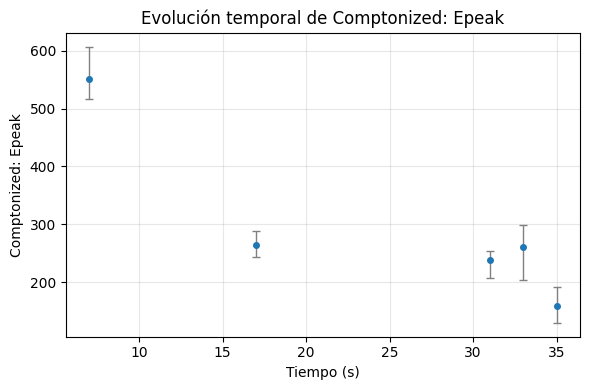

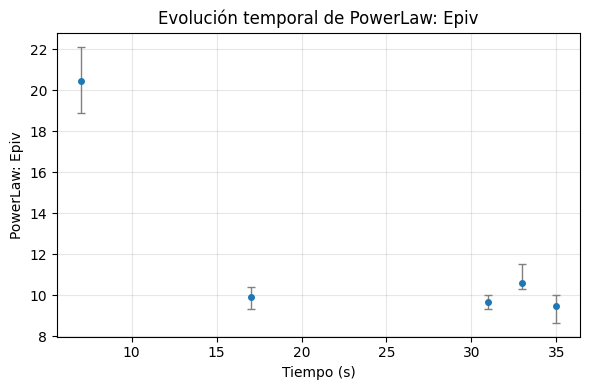

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar resultados
df = pd.read_csv("bb_fits_2012.csv")

# Calcular tiempo central de cada bin
df["t_center"] = 0.5 * (df["t_start"] + df["t_stop"])

# === Graficar cada parámetro ===
params = ["Comptonized: Epeak", "PowerLaw: Epiv"]

for p in params:
    if p not in df.columns:
        print(f"⚠️ {p} no está en el CSV, se omite.")
        continue

    err_low = df[f"{p}_err_low"].abs()
    err_high = df[f"{p}_err_high"].abs()

    plt.figure(figsize=(6, 4))
    plt.errorbar(
        df["t_center"],
        df[p],
        yerr=[err_low, err_high],
        fmt="o",
        ecolor="gray",
        elinewidth=1,
        capsize=3,
        ms=4,
        color="tab:blue"
    )
    plt.xlabel("Tiempo (s)")
    plt.ylabel(p)
    plt.title(f"Evolución temporal de {p}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
